In [1]:
# ==========================================
# VAE IMPLEMENTATION (COMPLETE)
# ==========================================


In [2]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense, Lambda
from tensorflow.keras.models import Model


c:\Users\mishr\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [3]:

# ------------------------------------------
# 1. Dataset (Structured random data)
# ------------------------------------------
np.random.seed(0)
X_train = np.random.rand(2000, 20)


In [4]:

# ------------------------------------------
# 2. Model Parameters
# ------------------------------------------
input_dim = 20
latent_dim = 2


In [12]:
# ------------------------------------------
# 3. Encoder
# ------------------------------------------
class Encoder(tf.keras.layers.Layer):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.dense1 = Dense(16, activation='relu')
        self.z_mean = Dense(latent_dim)
        self.z_log_var = Dense(latent_dim)
        self.latent_dim = latent_dim
    
    def call(self, x):
        h = self.dense1(x)
        z_mean = self.z_mean(h)
        z_log_var = self.z_log_var(h)
        
        # Sampling
        epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], self.latent_dim))
        z = z_mean + tf.exp(0.5 * z_log_var) * epsilon
        return z, z_mean, z_log_var

encoder = Encoder(latent_dim)

In [13]:
# ------------------------------------------
# 4. Decoder
# ------------------------------------------
class Decoder(tf.keras.layers.Layer):
    def __init__(self, output_dim):
        super(Decoder, self).__init__()
        self.dense1 = Dense(16, activation='relu')
        self.output_layer = Dense(output_dim, activation='sigmoid')
    
    def call(self, z):
        h = self.dense1(z)
        return self.output_layer(h)

decoder = Decoder(input_dim)

In [16]:
# ------------------------------------------
# 5. VAE Model
# ------------------------------------------
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, input_dim):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.input_dim = input_dim
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")
    
    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]
    
    def train_step(self, data):
        # Unpack data - data is a tuple (x, y) when calling fit(x, y)
        if isinstance(data, tuple):
            x, y = data
        else:
            x = data
            y = data
        
        with tf.GradientTape() as tape:
            z, z_mean, z_log_var = self.encoder(x, training=True)
            reconstruction = self.decoder(z, training=True)
            
            # Reconstruction loss
            reconstruction_loss = tf.reduce_mean(
                tf.keras.losses.mse(x, reconstruction)
            ) * self.input_dim
            
            # KL divergence loss
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )
            
            total_loss = reconstruction_loss + kl_loss
        
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        
        return {
            "total_loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }
    
    def call(self, x):
        z, z_mean, z_log_var = self.encoder(x)
        reconstruction = self.decoder(z)
        return reconstruction

vae = VAE(encoder, decoder, input_dim)
vae.compile(optimizer='adam')

In [17]:
# ------------------------------------------
# 6. Train
# ------------------------------------------
history = vae.fit(X_train, X_train, epochs=25, batch_size=32, verbose=1)

Epoch 1/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - kl_loss: 0.1010 - reconstruction_loss: 1.7319 - total_loss: 1.8329
Epoch 2/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - kl_loss: 0.0307 - reconstruction_loss: 1.6965 - total_loss: 1.7273
Epoch 3/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - kl_loss: 0.0175 - reconstruction_loss: 1.6892 - total_loss: 1.7067
Epoch 4/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - kl_loss: 0.0105 - reconstruction_loss: 1.6841 - total_loss: 1.6946
Epoch 5/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - kl_loss: 0.0067 - reconstruction_loss: 1.6791 - total_loss: 1.6859
Epoch 6/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - kl_loss: 0.0046 - reconstruction_loss: 1.6789 - total_loss: 1.6835
Epoch 7/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - kl_loss: 0.0033 - reconstruction_loss: 1.6793 - total_loss: 1.6826
Epoch 8/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - kl_loss: 0.0024 - reconstruction_loss: 1.6774 - total_loss: 1.6797
Epoch 9/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/ste

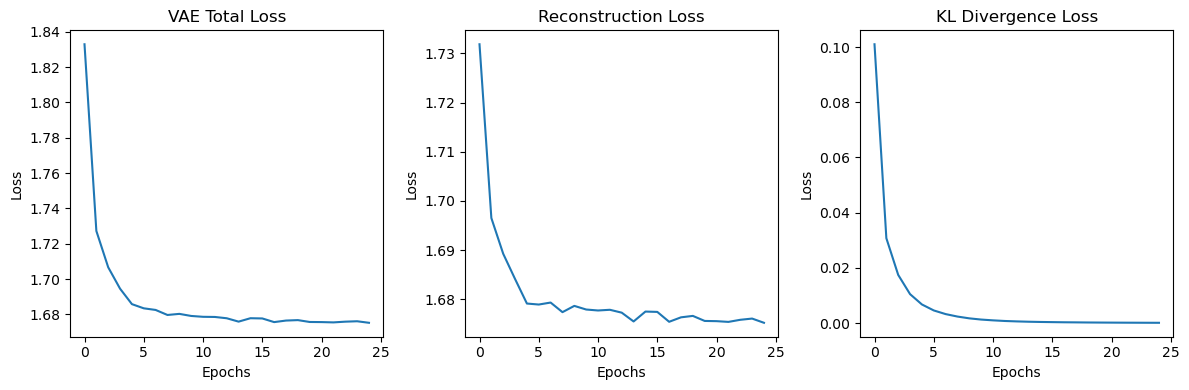

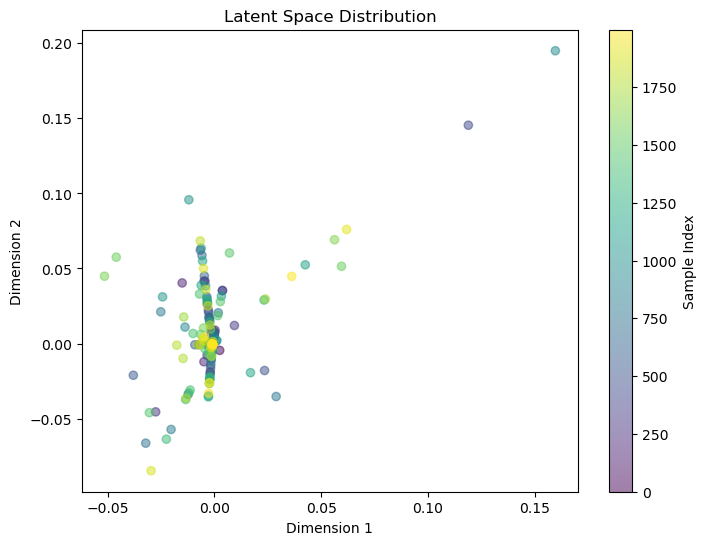

In [20]:
# ------------------------------------------
# 7. Visualization
# ------------------------------------------
plt.figure(figsize=(12, 4))

# Plot total loss
plt.subplot(1, 3, 1)
plt.plot(history.history['total_loss'])
plt.title("VAE Total Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

# Plot reconstruction loss
plt.subplot(1, 3, 2)
plt.plot(history.history['reconstruction_loss'])
plt.title("Reconstruction Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

# Plot KL loss
plt.subplot(1, 3, 3)
plt.plot(history.history['kl_loss'])
plt.title("KL Divergence Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

# Latent space visualization
z_vals = vae.encoder(X_train, training=False)[1]  # Get z_mean

plt.figure(figsize=(8, 6))
plt.scatter(z_vals[:, 0], z_vals[:, 1], alpha=0.5, c=np.arange(len(z_vals)), cmap='viridis')
plt.title("Latent Space Distribution")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.colorbar(label="Sample Index")
plt.show()